In [1]:
#libraries to use
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import sklearn.model_selection as ms
from sklearn import tree
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
#read in the csv
df = pd.read_csv("Crop_recommendationV2.csv")

In [3]:
#preview data 
df

,N,P,K,temperature,humidity,ph,rainfall,label,soil_moisture,soil_type,...,organic_matter,irrigation_frequency,crop_density,pest_pressure,fertilizer_usage,growth_stage,urban_area_proximity,water_source_type,frost_risk,water_usage_efficiency
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,29.446064,2,...,3.121395,4,11.743910,57.607308,188.194958,1,2.719614,3,95.649985,1.193293
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,12.851183,3,...,2.142021,4,16.797101,74.736879,70.963629,1,4.714427,2,77.265694,1.752672
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,29.363913,2,...,1.474974,1,12.654395,1.034478,191.976077,1,30.431736,2,18.192168,3.035541
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,26.207732,3,...,8.393907,1,10.864360,24.091888,55.761388,3,10.861071,3,82.818720,1.273341
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,28.236236,2,...,5.202285,3,13.852910,38.811481,185.259702,2,47.190777,3,25.466499,2.578671
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee,10.697757,1,...,4.720355,5,18.597260,87.431198,185.833381,3,31.415618,1,77.719639,4.111619
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee,12.203830,3,...,4.141148,6,15.417979,36.958354,198.541021,2,18.797510,3,22.336839,4.190796
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee,28.989176,3,...,1.599614,5,12.956675,79.678658,86.724381,2,38.805888,3,41.782729,2.447010
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee,13.642305,2,...,8.934077,6,16.868131,31.007156,72.191421,2,8.395498,3,49.619791,4.119388


In [4]:
#create a copy of df to work with
dfCopy = df.copy()

In [5]:
#running simple statistical checks on each columns 
#df.describe()
dfCopy.describe()

,N,P,K,temperature,humidity,ph,rainfall,soil_moisture,soil_type,sunlight_exposure,...,organic_matter,irrigation_frequency,crop_density,pest_pressure,fertilizer_usage,growth_stage,urban_area_proximity,water_source_type,frost_risk,water_usage_efficiency
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,...,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655,20.151388,1.991364,8.570609,...,5.465652,3.515000,12.344959,49.850701,125.846403,1.999545,24.801013,2.003636,50.304701,2.990268
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389,5.793720,0.812263,1.999382,...,2.605294,1.697912,4.297494,28.886354,43.564527,0.818999,14.523975,0.812021,28.580352,1.139637
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267,10.024260,1.000000,5.000710,...,1.003338,1.000000,5.004341,0.038103,50.209990,1.000000,0.017756,1.000000,0.054911,1.002106
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686,15.179949,1.000000,6.904620,...,3.203903,2.000000,8.585734,24.379866,88.030737,1.000000,12.212594,1.000000,26.104674,2.051814
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624,20.088481,2.000000,8.609968,...,5.418049,4.000000,12.303616,49.982421,126.441536,2.000000,24.922548,2.000000,50.171934,2.968675
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508,25.255146,3.000000,10.220394,...,7.686417,5.000000,15.975567,74.681904,163.850536,3.000000,37.322761,3.000000,75.262676,3.968736
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117,29.997860,3.000000,11.991041,...,9.999990,6.000000,19.988474,99.983850,199.982166,3.000000,49.992046,3.000000,99.957274,4.997130


In [6]:
#check dtypes+nulls
#df.info()
dfCopy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   N                       2200 non-null   int64  
 1   P                       2200 non-null   int64  
 2   K                       2200 non-null   int64  
 3   temperature             2200 non-null   float64
 4   humidity                2200 non-null   float64
 5   ph                      2200 non-null   float64
 6   rainfall                2200 non-null   float64
 7   label                   2200 non-null   object 
 8   soil_moisture           2200 non-null   float64
 9   soil_type               2200 non-null   int64  
 10  sunlight_exposure       2200 non-null   float64
 11  wind_speed              2200 non-null   float64
 12  co2_concentration       2200 non-null   float64
 13  organic_matter          2200 non-null   float64
 14  irrigation_frequency    2200 non-null   

In [7]:
#check for missing values
#print("Missing Values:")
#print(df.isnull().sum())
#print("\n")
#check for missing values
print("Missing Values:")
print(dfCopy.isnull().sum())
print("\n")

Missing Values:
N                         0
P                         0
K                         0
temperature               0
humidity                  0
ph                        0
rainfall                  0
label                     0
soil_moisture             0
soil_type                 0
sunlight_exposure         0
wind_speed                0
co2_concentration         0
organic_matter            0
irrigation_frequency      0
crop_density              0
pest_pressure             0
fertilizer_usage          0
growth_stage              0
urban_area_proximity      0
water_source_type         0
frost_risk                0
water_usage_efficiency    0
dtype: int64




In [8]:
#check for duplicate rows
#print("Duplicate Rows:", df.duplicated())
print("Duplicate Rows:", dfCopy.duplicated())

Duplicate Rows: 0       False
1       False
2       False
3       False
4       False
        ...  
2195    False
2196    False
2197    False
2198    False
2199    False
Length: 2200, dtype: bool


In [9]:
#check for duplicate values 
#print("Duplicate Values:", df.nunique())
print("Duplicate Values:", dfCopy.nunique())


Duplicate Values: N                          137
P                          117
K                           73
temperature               2200
humidity                  2200
ph                        2200
rainfall                  2200
label                       22
soil_moisture             2200
soil_type                    3
sunlight_exposure         2200
wind_speed                2200
co2_concentration         2200
organic_matter            2200
irrigation_frequency         6
crop_density              2200
pest_pressure             2200
fertilizer_usage          2200
growth_stage                 3
urban_area_proximity      2200
water_source_type            3
frost_risk                2200
water_usage_efficiency    2200
dtype: int64


In [10]:
#checking the ranges of specific values 
print("pH range:", dfCopy['ph'].min(), "-", dfCopy['ph'].max())
print("Temperature range:", dfCopy['temperature'].min(), "-", dfCopy['temperature'].max())
print("Rainfall range:", dfCopy['rainfall'].min(), "-", dfCopy['rainfall'].max())


pH range: 3.504752314 - 9.93509073
Temperature range: 8.825674745 - 43.67549305
Rainfall range: 20.21126747 - 298.5601175


In [11]:
#creating the derived features - temperature-humidity index
#formula to calculate HI=0.5×{T+61.0+[(T−68.0)×1.2]+(RH×0.094)}

#convert Celsius to Fahrenheit
dfCopy['temperatureInFahrenheit'] = dfCopy['temperature'] * 9/5 + 32

#calculate THI (Temperature-Humidity Index)
dfCopy['THI'] = 0.5 * (dfCopy['temperatureInFahrenheit'] + 61.0 + ((dfCopy['temperatureInFahrenheit'] - 68.0) * 1.2) + (dfCopy['humidity'] * 0.094))

#preview the new column
print(dfCopy[['temperature', 'humidity', 'temperatureInFahrenheit', 'THI']].head())


   temperature   humidity  temperatureInFahrenheit        THI
0    20.879744  82.002744                69.583539  70.096022
1    21.770462  80.319644                71.186831  71.780537
2    23.004459  82.320763                73.408026  74.317905
3    26.491096  80.158363                79.683973  81.119814
4    20.130175  81.604873                68.234315  68.593175


In [12]:
#nutrient balance ratio - Reflects the balance between nitrogen, phosphorus, and potassium in the soil
dfCopy['NBR'] = (dfCopy['N'] + dfCopy['P'] + dfCopy['K']) / 3

#preview new column
print(dfCopy['NBR'])

0       58.333333
1       61.333333
2       53.000000
3       49.666667
4       54.000000
          ...    
2195    57.666667
2196    47.000000
2197    60.333333
2198    61.000000
2199    50.666667
Name: NBR, Length: 2200, dtype: float64


In [13]:
#water availabiltiy index - Combines soil moisture and rainfall to assess overall water availability for crops
dfCopy['WAI'] = dfCopy['soil_moisture'] + dfCopy['rainfall']

#preview new column
print(dfCopy['WAI'])

0       232.381600
1       239.506720
2       293.328160
3       269.071767
4       290.953577
           ...    
2195    188.472264
2196    140.128440
2197    202.312014
2198    140.817598
2199    164.848769
Name: WAI, Length: 2200, dtype: float64


In [14]:
#photosynthesis potential - Estimates the potential for photosynthesis based on sunlight exposure, CO2 concentration, and temperature
dfCopy['PP'] = dfCopy['sunlight_exposure'] * dfCopy['co2_concentration'] * dfCopy['temperature']

#preview new column
print(dfCopy['PP'])

0        78924.457470
1        50291.281745
2        81196.185256
3        77305.481010
4        67079.871974
            ...      
2195    121451.656231
2196     67450.255433
2197     96535.419556
2198     88395.113744
2199     84245.822215
Name: PP, Length: 2200, dtype: float64


In [15]:
#soil fertility index - A composite metric that assesses soil fertility based on organic matter content and NPK levels
dfCopy['SFI'] = dfCopy['organic_matter'] * (dfCopy['N'] + dfCopy['P'] + dfCopy['K'])

#preview new column
print(dfCopy['SFI'])

0        546.244038
1        394.131851
2        234.520822
3       1250.692169
4        842.770240
           ...     
2195     816.621375
2196     583.901835
2197     289.530143
2198    1634.936079
2199     973.103044
Name: SFI, Length: 2200, dtype: float64


In [16]:
#making a makeshift "crop yield" variable, crop yield is the amount of crop harvested per unit area in kg/ha

#so we need to create a average yield per plant variable 
#yield per plant increases with nutrients photosynthesis and water and decreases if pests or frost are high
dfCopy['estimatedAverageYieldPerPlant'] = (
    (dfCopy['fertilizer_usage'] + dfCopy['SFI'] + dfCopy['PP']) * (dfCopy['WAI']) * (dfCopy['growth_stage'] / 3)) / (1 + dfCopy['pest_pressure'] + dfCopy['frost_risk']  )

#estimate crop yield as crop_density * estimated average yield per plant
dfCopy['cropYield'] = dfCopy['crop_density'] * dfCopy['estimatedAverageYieldPerPlant']


In [17]:
#creating a new cropYield column but logged to adjust for skeweness 
dfCopy['logCropYield'] = np.log1p(dfCopy['cropYield'])

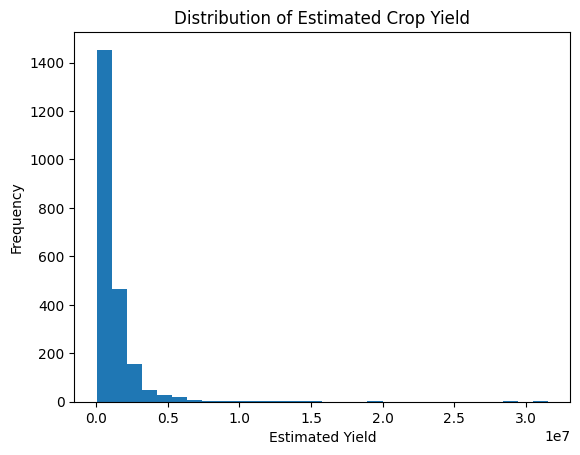

In [18]:
#lets check right now whether log crop yield is valid by plotting
plt.hist(dfCopy['cropYield'], bins=30)
plt.title("Distribution of Estimated Crop Yield")
plt.xlabel("Estimated Yield")
plt.ylabel("Frequency")
plt.show()


In [19]:
#check correlations with related variables used in to create this variable 
print(dfCopy[['cropYield', 'fertilizer_usage', 'SFI', 'PP', 'WAI']].corr())

                  cropYield  fertilizer_usage       SFI        PP       WAI
cropYield          1.000000          0.006614 -0.033413  0.208854  0.283997
fertilizer_usage   0.006614          1.000000 -0.013166  0.014035 -0.011394
SFI               -0.033413         -0.013166  1.000000 -0.052566 -0.024453
PP                 0.208854          0.014035 -0.052566  1.000000 -0.010373
WAI                0.283997         -0.011394 -0.024453 -0.010373  1.000000


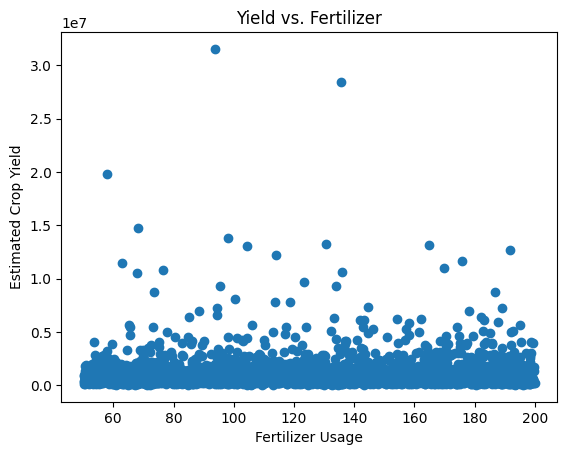

In [20]:
#creating a scatter plot to see if the relationships are behaving logically
plt.scatter(dfCopy['fertilizer_usage'], dfCopy['cropYield'])
plt.xlabel("Fertilizer Usage")
plt.ylabel("Estimated Crop Yield")
plt.title("Yield vs. Fertilizer")
plt.show()

In [21]:
#check how the cropYield variable reacts across all three stages, the higher the stage the more it should have, aka crop yield more 
dfCopy.groupby('growth_stage')['cropYield'].mean()


growth_stage
1    6.031874e+05
2    1.220119e+06
3    1.763902e+06
Name: cropYield, dtype: float64

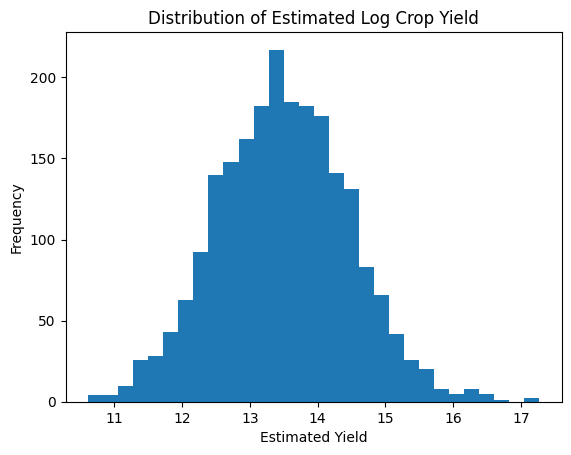

In [22]:
#lets check right now whether log crop yield is valid since we noticed crop yield was a skewed 
plt.hist(dfCopy['logCropYield'], bins=30)
plt.title("Distribution of Estimated Log Crop Yield")
plt.xlabel("Estimated Yield")
plt.ylabel("Frequency")
plt.show()

In [23]:
#check correlations with related variables used in the log variation of crop yield
print(dfCopy[['logCropYield', 'fertilizer_usage', 'SFI', 'PP', 'WAI']].corr())

                  logCropYield  fertilizer_usage       SFI        PP       WAI
logCropYield          1.000000          0.009403 -0.035655  0.336589  0.423151
fertilizer_usage      0.009403          1.000000 -0.013166  0.014035 -0.011394
SFI                  -0.035655         -0.013166  1.000000 -0.052566 -0.024453
PP                    0.336589          0.014035 -0.052566  1.000000 -0.010373
WAI                   0.423151         -0.011394 -0.024453 -0.010373  1.000000


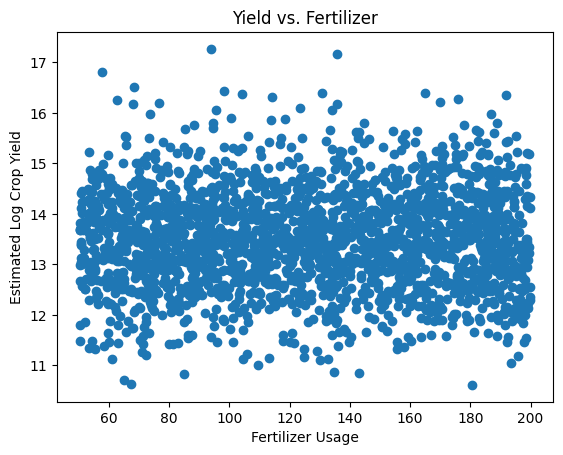

In [24]:
#creating a scatter plot to see if the relationships are behaving logically
plt.scatter(dfCopy['fertilizer_usage'], dfCopy['logCropYield'])
plt.xlabel("Fertilizer Usage")
plt.ylabel("Estimated Log Crop Yield")
plt.title("Yield vs. Fertilizer")
plt.show()

In [25]:
#we see that log crop yield is behaving properly since their is an estimate of more yield in the later stages 
dfCopy.groupby('growth_stage')['logCropYield'].mean()

growth_stage
1    12.894460
2    13.590198
3    14.009327
Name: logCropYield, dtype: float64

In [26]:
#EDA of certain variables - logCropYield
#print("Summary stats for logCropYield:")
print(dfCopy['logCropYield'].describe())
print(dfCopy['cropYield'].describe())
print(dfCopy['fertilizer_usage'].describe())

count    2200.000000
mean       13.497218
std         0.971428
min        10.614978
25%        12.826297
50%        13.480327
75%        14.149519
max        17.267132
Name: logCropYield, dtype: float64
count    2.200000e+03
mean     1.195334e+06
std      1.732561e+06
min      4.073949e+04
25%      3.718680e+05
50%      7.152061e+05
75%      1.396554e+06
max      3.155152e+07
Name: cropYield, dtype: float64
count    2200.000000
mean      125.846403
std        43.564527
min        50.209990
25%        88.030737
50%       126.441536
75%       163.850536
max       199.982166
Name: fertilizer_usage, dtype: float64


In [27]:
meanLCY = np.exp(13.497218)
minLCY = np.exp(10.614978)
quarterLCY = np.exp(12.826297)
medianLCY = np.exp(13.4803217)
threequarterLCY = np.exp(14.149519)
maxLCY = np.exp(17.267132)

print(meanLCY)
print(minLCY)
print(quarterLCY)
print(medianLCY)
print(threequarterLCY)
print(maxLCY)

727389.953558801
40740.50152141728
371869.02948992397
715203.0018141001
1396554.9332913803
31551509.79980427


In [28]:
#my model to answer - Can crops maintain performance under reduced fertilizer usage, and which soil factors compensate for low fertilizer availability? 

In [29]:
numericCols = dfCopy.select_dtypes(include='number')

#check correlation with Crop Yield 
correlations = numericCols.corr()['cropYield'].sort_values(ascending=False)

print("Correlation with Crop Yield:")
print(correlations)

Correlation with Crop Yield:
cropYield                        1.000000
estimatedAverageYieldPerPlant    0.897449
logCropYield                     0.728928
WAI                              0.283997
rainfall                         0.282117
growth_stage                     0.274345
crop_density                     0.233593
PP                               0.208854
sunlight_exposure                0.179607
temperature                      0.118528
temperatureInFahrenheit          0.118528
THI                              0.117673
irrigation_frequency             0.036122
water_source_type                0.032089
N                                0.026078
humidity                         0.021711
soil_moisture                    0.018998
co2_concentration                0.017809
soil_type                        0.016573
fertilizer_usage                 0.006614
urban_area_proximity            -0.000987
organic_matter                  -0.002625
wind_speed                      -0.006580
water

In [30]:
numericCols = dfCopy.select_dtypes(include='number')

#check correlation with Crop Yield 
correlations = numericCols.corr()['logCropYield'].sort_values(ascending=False)

print("Correlation with Log Crop Yield:")
print(correlations)

Correlation with Log Crop Yield:
logCropYield                     1.000000
cropYield                        0.728928
estimatedAverageYieldPerPlant    0.623190
growth_stage                     0.469991
WAI                              0.423151
rainfall                         0.419329
crop_density                     0.409648
PP                               0.336589
sunlight_exposure                0.288333
temperature                      0.190734
temperatureInFahrenheit          0.190734
THI                              0.190203
co2_concentration                0.054454
soil_type                        0.049778
humidity                         0.043249
soil_moisture                    0.037997
irrigation_frequency             0.035399
N                                0.031006
water_source_type                0.028439
organic_matter                   0.027855
fertilizer_usage                 0.009403
wind_speed                      -0.000701
water_usage_efficiency          -0.005887
u

In [31]:
#define features and target
features = ['fertilizer_usage', 'WAI', 'rainfall', 'PP', 'THI', 'pest_pressure', 'frost_risk', 'growth_stage', 'crop_density']
X = dfCopy[features]
Y = dfCopy['logCropYield']

#split data into train/test sets
XTrain, XTest, YTrain, YTest = ms.train_test_split(X, Y, test_size=0.3, random_state=1)

#define parameter ranges
depth_val = np.arange(2, 11)
leaf_val = np.arange(1, 31, step=5)

#grid search parameters
gridSearch = [{'max_depth': depth_val, 'min_samples_leaf': leaf_val}]
model = tree.DecisionTreeRegressor()

cv_tree = GridSearchCV(estimator=model, param_grid=gridSearch, cv=ms.KFold(n_splits=5))
cv_tree.fit(XTrain, YTrain)

#best parameters
best_depth = cv_tree.best_params_['max_depth']
best_leaf = cv_tree.best_params_['min_samples_leaf']
print("Best Depth:", best_depth)
print("Best Min Samples Leaf:", best_leaf)

#fit final model with best parameters
FinalTree = tree.DecisionTreeRegressor(max_depth=best_depth, min_samples_leaf=best_leaf)
FinalTree.fit(XTrain, YTrain)

#predict on test set
YPred = FinalTree.predict(XTest)

#evaluate performance
print("MSE:", mean_squared_error(YTest, YPred))
print("R² Score:", r2_score(YTest, YPred))


Best Depth: 10
Best Min Samples Leaf: 6
MSE: 0.22841910008232078
R² Score: 0.7541096199784009


In [32]:
tree.export_graphviz(
    FinalTree,  # this is your trained model
    out_file="tree.dot",  # saves the file locally
    feature_names=features,  # names of input features
    filled=True,  # color nodes based on prediction
    rounded=True,  # rounded box edges
    max_depth=10
)


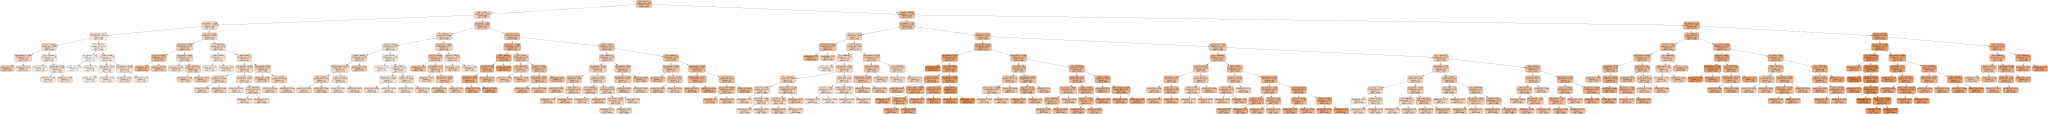

In [33]:
import graphviz

with open("tree.dot") as f:
    dot_graph = f.read()

graphviz.Source(dot_graph)


In [34]:
dfCopy

,N,P,K,temperature,humidity,ph,rainfall,label,soil_moisture,soil_type,...,water_usage_efficiency,temperatureInFahrenheit,THI,NBR,WAI,PP,SFI,estimatedAverageYieldPerPlant,cropYield,logCropYield
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,29.446064,2,...,1.193293,69.583539,70.096022,58.333333,232.381600,78924.457470,546.244038,40000.835408,4.697662e+05,13.059993
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,12.851183,3,...,1.752672,71.186831,71.780537,61.333333,239.506720,50291.281745,394.131851,26484.289813,4.448593e+05,13.005516
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,29.363913,2,...,3.035541,73.408026,74.317905,53.000000,293.328160,81196.185256,234.520822,394565.850841,4.992992e+06,15.423546
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,26.207732,3,...,1.273341,79.683973,81.119814,49.666667,269.071767,77305.481010,1250.692169,196016.429538,2.129593e+06,14.571442
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,28.236236,2,...,2.578671,68.234315,68.593175,54.000000,290.953577,67079.871974,842.770240,202377.969290,2.803524e+06,14.846388
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee,10.697757,1,...,4.111619,80.194347,81.035205,57.666667,188.472264,121451.656231,816.621375,138905.129134,2.583255e+06,14.764561
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee,12.203830,3,...,4.190796,81.350802,81.847792,47.000000,140.128440,67450.255433,583.901835,105717.012923,1.629943e+06,14.304056
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee,28.989176,3,...,2.447010,75.437234,75.840539,60.333333,202.312014,96535.419556,289.530143,106735.118331,1.382932e+06,14.139717
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee,13.642305,2,...,4.119388,79.290353,79.369376,61.000000,140.817598,88395.113744,1634.936079,103625.755106,1.747973e+06,14.373968


In [35]:
#Can crops maintain performance under reduced fertilizer usage?
#define what counts as "low" fertilizer usage 
lowFertilizerThreshold = dfCopy['fertilizer_usage'].quantile(0.25)
#check
#print(lowFertilizerThreshold)
#subset the data
lowFertilizerData = dfCopy[dfCopy['fertilizer_usage'] <= lowFertilizerThreshold]
#check
#print(low_fert_data)
#predict yields using your model
lowFertilizerPredictions = FinalTree.predict(lowFertilizerData[features])

#add predictions to the subset
lowFertilizerData = lowFertilizerData.copy()
lowFertilizerData['predicted_logYield'] = lowFertilizerPredictions

#check average yield under low fertilizer
print("Avg logYield under low fertilizer:", lowFertilizerData['predicted_logYield'].mean())

#compare to the overall average yield
print("Overall average logCropYield:", dfCopy['logCropYield'].mean())


Avg logYield under low fertilizer: 13.44098496194514
Overall average logCropYield: 13.49721790326226


In [36]:
lowFertilizerYield = np.exp(13.44098496194514)
print(lowFertilizerYield)
overallAverageYield = np.exp(13.49721790326226)
print(overallAverageYield)

687615.4089134352
727389.8831927445


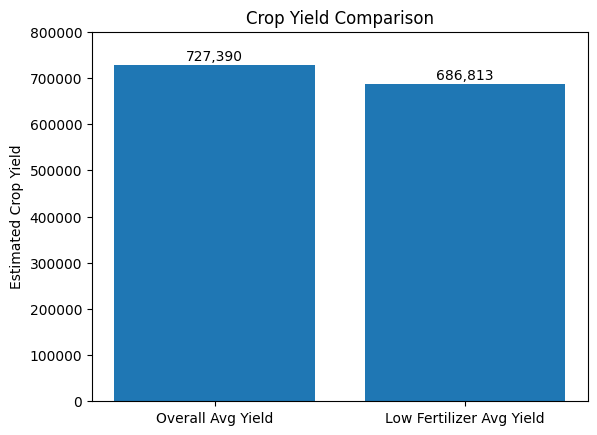

In [37]:
#real-world yield values
labels = ['Overall Avg Yield', 'Low Fertilizer Avg Yield']
values = [727390, 686813] 

plt.bar(labels, values)
plt.ylabel('Estimated Crop Yield')
plt.title('Crop Yield Comparison')
plt.ylim(0, max(values)*1.1)

#add text labels
for i, val in enumerate(values):  plt.text(i, val + 10000, f'{val:,.0f}', ha='center')

plt.show()


In [38]:
#Which soil/environmental factors compensate for low fertilizer?
#aka what variables allow crops to still perform well even when fertilizier is low
#define what counts as a good performnace by using the median since median isnt sensitive to outliers
#splitting in half for what high and low crop yield is
medianYield = dfCopy['logCropYield'].median()
#subset to focus on high yield + low fertilizer 
highYieldLowFertilizer = lowFertilizerData[lowFertilizerData['predicted_logYield'] >= medianYield]
#now we will look at the average values of the soil/environemtn features in these rows  (using the features used in model)
analysisVariables = features + ['SFI']
#average values in high yield low fertilizer 
highYieldConditions = highYieldLowFertilizer[analysisVariables].mean()
print("Average values when crops high yield and low fertilizer:\n")
print(highYieldConditions)
#comparing with low yield low fertility 
lowYieldLowFertilizer = lowFertilizerData[lowFertilizerData['predicted_logYield'] < medianYield]
lowYieldConditions = lowYieldLowFertilizer[analysisVariables].mean()
print("\nAverage values when crops low yield low fertilizer:\n")
print(lowYieldConditions)


Average values when crops high yield and low fertilizer:

fertilizer_usage       69.616926
WAI                   148.332350
rainfall              128.051757
PP                  95601.261048
THI                    80.328780
pest_pressure          44.206521
frost_risk             45.449910
growth_stage            2.284672
crop_density           13.488208
SFI                   792.393275
dtype: float64

Average values when crops low yield low fertilizer:

fertilizer_usage       69.244134
WAI                   103.308767
rainfall               83.310643
PP                  78798.170009
THI                    77.309819
pest_pressure          58.237515
frost_risk             57.577253
growth_stage            1.699275
crop_density           10.947913
SFI                   908.476419
dtype: float64


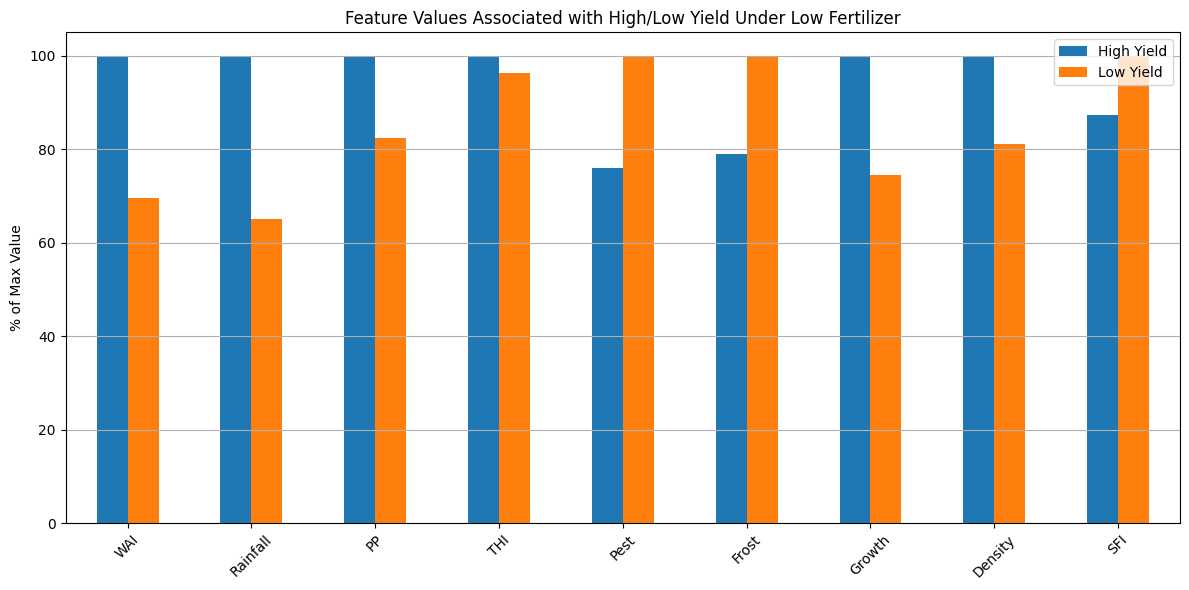

In [39]:
#raw data
high = [148.33, 128.05, 95601.26, 80.33, 44.21, 45.45, 2.28, 13.49, 792.39]
low =  [103.31, 83.31, 78798.17, 77.31, 58.24, 57.58, 1.70, 10.95, 908.48]
labels = ['WAI', 'Rainfall', 'PP', 'THI', 'Pest', 'Frost', 'Growth', 'Density', 'SFI']

dfCopy = pd.DataFrame({'High Yield': high, 'Low Yield': low}, index=labels)
dfNormalized = dfCopy.div(dfCopy.max(axis=1), axis=0) * 100

dfNormalized.plot(kind='bar', figsize=(12, 6))
plt.title('Feature Values Associated with High/Low Yield Under Low Fertilizer')
plt.ylabel('% of Max Value')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [40]:
dfCopy.to_csv('caiProject.csv', index=False)


In [41]:
dfCopy

,High Yield,Low Yield
WAI,148.33,103.31
Rainfall,128.05,83.31
PP,95601.26,78798.17
THI,80.33,77.31
Pest,44.21,58.24
Frost,45.45,57.58
Growth,2.28,1.70
Density,13.49,10.95
SFI,792.39,908.48
